<a href="https://colab.research.google.com/github/xyhosino/Machine_Learning/blob/main/%E6%9C%BA%E5%99%A8%E5%AD%A6%E4%B9%A0_%E7%AC%AC9%E8%AF%BE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np # 基础线性代数扩展包
import pandas as pd # 数据处理工具箱
df_bank = pd.read_csv("/content/BankCustomer.csv") # 读取文件
df_bank.head() # 显示文件前5行

,Name,Gender,Age,City,Tenure,ProductsNo,HasCard,ActiveMember,Credit,AccountBal,Salary,Exited
0,Kan Jian,Female,40,Beijing,9,2,0,1,516,6360.66,0.0000,0
1,Xue Baochai,Male,69,Beijing,6,2,0,1,682,28605.00,0.0000,0
2,Mao Xi,Female,32,Beijing,9,1,1,1,803,10378.09,236311.0932,1
3,Zheng Nengliang,Female,37,Tianjin,0,2,1,1,778,25564.01,129909.8079,1
4,Zhi Fen,Male,55,Tianjin,4,3,1,0,547,3235.61,136976.1948,1


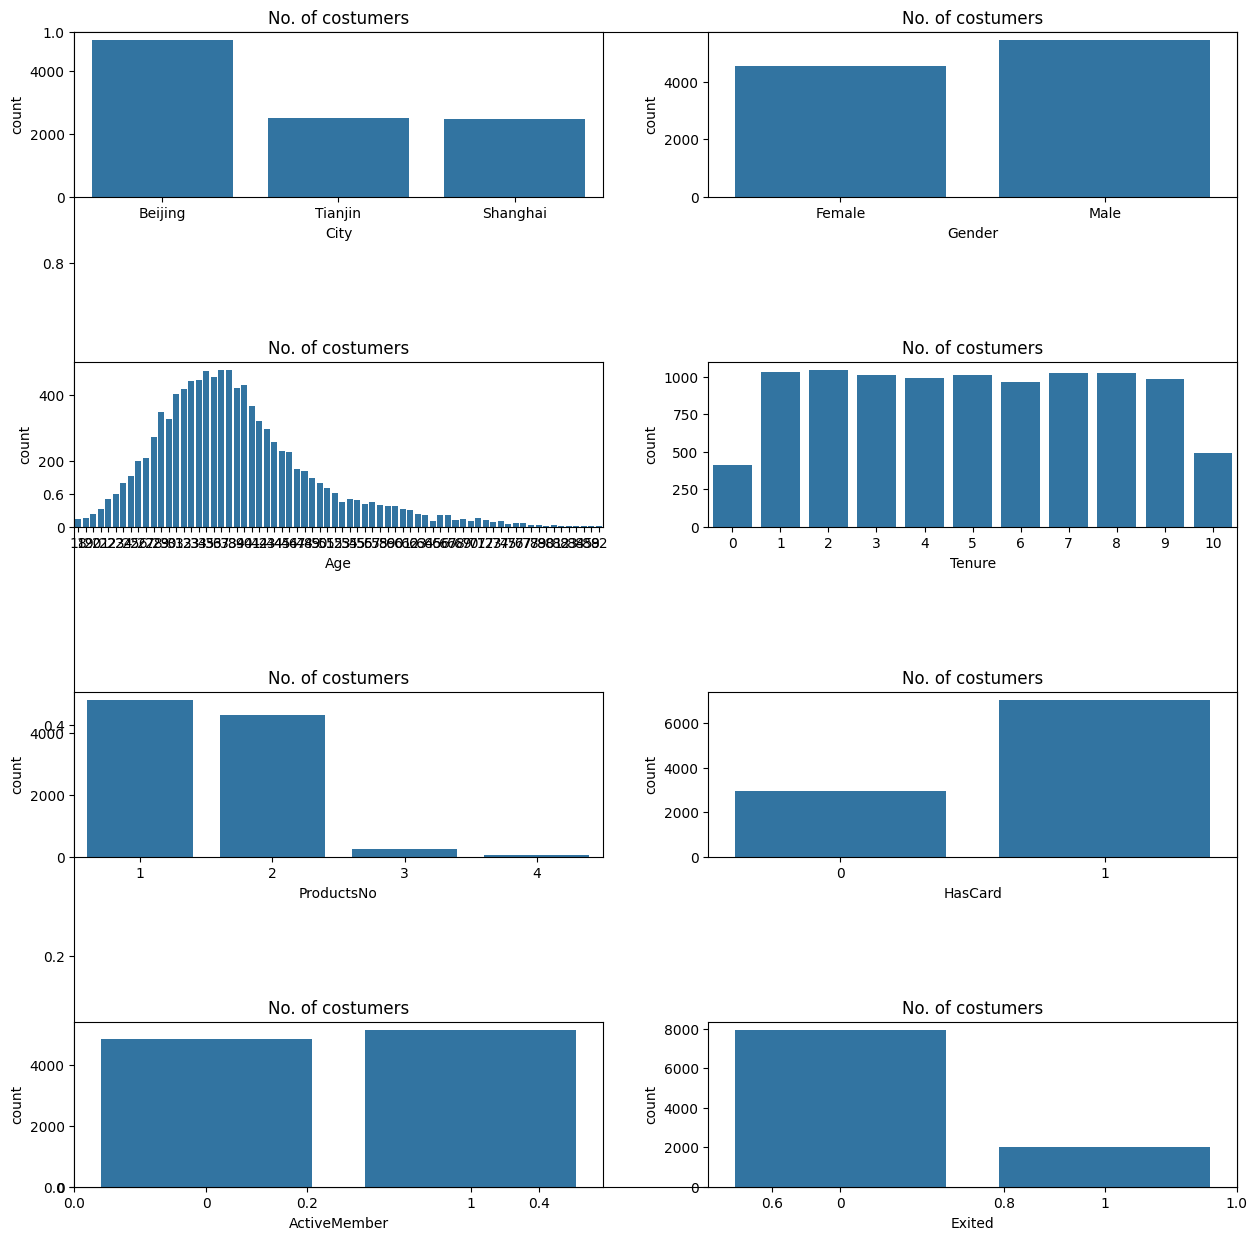

In [2]:
import matplotlib.pyplot as plt #导入matplotlib画图工具箱
import seaborn as sns #导入seaborn画图工具箱
# 显示不同特征的分布情况
features=[ 'City', 'Gender','Age','Tenure',
           'ProductsNo', 'HasCard', 'ActiveMember', 'Exited']
fig=plt.subplots(figsize=(15,15))
for i, j in enumerate(features):
    plt.subplot(4, 2, i+1) # i+1:确定当前的小图画在哪个格子
    plt.subplots_adjust(hspace = 1.0)
    sns.countplot(x = j, data = df_bank)
    plt.title("No. of costumers")

In [3]:
# 数字化性别
df_bank['Gender'].replace({"Female": 0, "Male": 1}, inplace=True)
# 显示数字类别
print("Gender unique values",df_bank['Gender'].unique())
# 把多元类别转换成多个二元哑变量，然后贴回原始数据集
d_city = pd.get_dummies(df_bank['City'], prefix = "City", dtype=int)
df_bank = pd.concat([df_bank, d_city], axis=1)
# 构建特征和标签集合
y = df_bank['Exited']
X = df_bank.drop(['Name', 'Exited', 'City'], axis=1)
X.head() #显示新的特征集

Gender unique values [0 1]


/tmp/ipykernel_11635/473037244.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_bank['Gender'].replace({"Female": 0, "Male": 1}, inplace=True)
/tmp/ipykernel_11635/473037244.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_bank['Gender'].replace({"Female": 0, "Male": 1}, inplace=True)


,Gender,Age,Tenure,ProductsNo,HasCard,ActiveMember,Credit,AccountBal,Salary,City_Beijing,City_Shanghai,City_Tianjin
0,0,40,9,2,0,1,516,6360.66,0.0000,1,0,0
1,1,69,6,2,0,1,682,28605.00,0.0000,1,0,0
2,0,32,9,1,1,1,803,10378.09,236311.0932,1,0,0
3,0,37,0,2,1,1,778,25564.01,129909.8079,0,0,1
4,1,55,4,3,1,0,547,3235.61,136976.1948,0,0,1


In [5]:
from sklearn.model_selection import train_test_split # 拆分数据集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [6]:
print(X_train.dtypes)

Gender             int64
Age                int64
Tenure             int64
ProductsNo         int64
HasCard            int64
ActiveMember       int64
Credit             int64
AccountBal       float64
Salary           float64
City_Beijing       int64
City_Shanghai      int64
City_Tianjin       int64
dtype: object


In [7]:
# 对多棵决策树进行Bagging，即树的聚合
from sklearn.ensemble import BaggingClassifier # 导入Bagging分类器
from sklearn.tree import DecisionTreeClassifier # 导入决策树分类器
from sklearn.metrics import (f1_score, confusion_matrix) # 导入评估标准
dt = DecisionTreeClassifier() # 只使用一棵决策树
dt.fit(X_train, y_train) # 拟合模型
y_pred = dt.predict(X_test) # 进行预测
print("决策树测试准确率: {:.2f}%".format(dt.score(X_test, y_test)*100))
print("决策树测试F1分数: {:.2f}%".format(f1_score(y_test, y_pred)*100))
bdt = BaggingClassifier(DecisionTreeClassifier()) #树的Bagging
bdt.fit(X_train, y_train) # 拟合模型
y_pred = bdt.predict(X_test) # 进行预测
print("决策树Bagging测试准确率: {:.2f}%".format(bdt.score(X_test, y_test)*100))
print("决策树Bagging测试F1分数: {:.2f}%".format(f1_score(y_test, y_pred)*100))

决策树测试准确率: 79.65%
决策树测试F1分数: 51.14%
决策树Bagging测试准确率: 85.00%
决策树Bagging测试F1分数: 55.22%


In [9]:
from sklearn.model_selection import GridSearchCV # 导入网格搜索工具
# 使用网格搜索优化参数
bdt_param_grid = {
    'estimator__max_depth' : [5,10,20,50,100],
    'n_estimators' : [1, 5, 10, 50]}

bdt_gs = GridSearchCV(
    BaggingClassifier(DecisionTreeClassifier()),
    param_grid = bdt_param_grid,
    scoring = 'f1',
    n_jobs= 10,
    verbose = 1
    )
bdt_gs.fit(X_train, y_train) # 拟合模型

best_bdt = bdt_gs.best_estimator_ # 最佳模型

y_pred = best_bdt.predict(X_test) # 进行预测

print("决策树Bagging最佳参数: {}".format(bdt_gs.best_params_))
print("决策树Bagging测试准确率: {:.2f}%".format(best_bdt.score(X_test, y_test)*100))
print("决策树Bagging测试F1分数: {:.2f}%".format(f1_score(y_test, y_pred)*100))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
决策树Bagging最佳参数: {'estimator__max_depth': 10, 'n_estimators': 50}
决策树Bagging测试准确率: 86.85%
决策树Bagging测试F1分数: 61.27%


In [18]:
from sklearn.ensemble import RandomForestClassifier # 导入随机森林分类器
rf = RandomForestClassifier() # 随机森林模型
# 使用网格搜索优化参数
rf_param_grid = {"max_depth": [None],
              "max_features": [1, 3, 10],
               "min_samples_split": [2, 3, 10],
               "min_samples_leaf": [1, 3, 10],
              "bootstrap": [True,False],
              "n_estimators" :[100,300],
              "criterion": ["gini"]}
rf_gs = GridSearchCV(
    rf,
    param_grid = rf_param_grid,
    scoring="f1",
    n_jobs= 10,
    verbose = 1)

rf_gs.fit(X_train,y_train) # 拟合模型

best_rf = rf_gs.best_estimator_ # 最佳模型

y_pred = best_rf.predict(X_test) # 进行预测

print("随机森林测试准确率: {:.2f}%".format(best_rf.score(X_test, y_test)*100))
print("随机森林测试F1分数: {:.2f}%".format(f1_score(y_test, y_pred)*100))

Fitting 5 folds for each of 108 candidates, totalling 540 fits
随机森林测试准确率: 86.40%
随机森林测试F1分数: 60.00%


In [19]:
from sklearn.ensemble import ExtraTreesClassifier # 导入极端随机森林模型
ext = ExtraTreesClassifier() # 极端随机森林模型
# 使用网格搜索优化参数
ext_param_grid = {"max_depth": [None],
              "max_features": [1, 3, 10],
              "min_samples_split": [2, 3, 10],
              "min_samples_leaf": [1, 3, 10],
              "bootstrap": [True,False],
              "n_estimators" :[100,300],
              "criterion": ["gini"]}
ext_gs = GridSearchCV(ext,param_grid = ext_param_grid, scoring="f1",
                     n_jobs= 4, verbose = 1)
ext_gs.fit(X_train,y_train) # 拟合模型
best_ext = ext_gs.best_estimator_ # 最佳模型
y_pred = best_ext.predict(X_test) # 进行预测
print("更多树测试准确率: {:.2f}%".format(best_ext.score(X_test, y_test)*100))
print("更多树测试F1分数: {:.2f}%".format(f1_score(y_test, y_pred)*100))

Fitting 5 folds for each of 108 candidates, totalling 540 fits
更多树测试准确率: 86.25%
更多树测试F1分数: 59.14%


In [10]:
from sklearn.ensemble import AdaBoostClassifier # 导入AdaBoost模型
dt = DecisionTreeClassifier() # 选择决策树分类器作为AdaBoost的基准算法
ada = AdaBoostClassifier(dt) # AdaBoost模型
# 使用网格搜索优化参数
ada_param_grid = {"estimator__criterion" : ["gini", "entropy"],
                  "estimator__splitter" :   ["best", "random"],
                  "estimator__random_state" :   [7,9,10,12,15],
                  # "algorithm" : ["SAMME","SAMME.R"],
                  "n_estimators" :[1,2,5,10],
                  "learning_rate":  [0.0001, 0.001, 0.01, 0.1, 0.2, 0.3,1.5]}
ada_gs = GridSearchCV(ada,param_grid = ada_param_grid,
                        scoring="f1", n_jobs= 10, verbose = 1)
ada_gs.fit(X_train,y_train) # 拟合模型
best_ada = ada_gs.best_estimator_ # 最佳模型
y_pred = best_ada.predict(X_test) # 进行预测
print("Adaboost测试准确率: {:.2f}%".format(best_ada.score(X_test, y_test)*100))
print("Adaboost测试F1分数: {:.2f}%".format(f1_score(y_test, y_pred)*100))

Fitting 5 folds for each of 560 candidates, totalling 2800 fits
Adaboost测试准确率: 78.10%
Adaboost测试F1分数: 48.10%


In [11]:
from sklearn.ensemble import GradientBoostingClassifier # 导入梯度提升分类器
gb = GradientBoostingClassifier() # 梯度提升分类器
# 使用网格搜索优化参数
gb_param_grid = {'loss' : ["log_loss"],
                 'n_estimators' : [100,200,300],
                 'learning_rate': [0.1, 0.05, 0.01],
                 'max_depth': [4, 8],
                 'min_samples_leaf': [100,150],
                 'max_features': [0.3, 0.1]}
gb_gs = GridSearchCV(gb,param_grid = gb_param_grid,
                     scoring="f1", n_jobs= 10, verbose = 1)
gb_gs.fit(X_train,y_train) # 拟合模型
best_gb = gb_gs.best_estimator_ # 最佳模型
y_pred = best_gb.predict(X_test) # 进行预测
print("梯度提升测试准确率: {:.2f}%".format(best_gb.score(X_test, y_test)*100))
print("梯度提升测试F1分数: {:.2f}%".format(f1_score(y_test, y_pred)*100))

Fitting 5 folds for each of 72 candidates, totalling 360 fits
梯度提升测试准确率: 86.55%
梯度提升测试F1分数: 61.18%


In [12]:
pip install xgboost

In [13]:
from xgboost import XGBClassifier # 导入XGB分类器
xgb = XGBClassifier() # XGB分类器
# 使用网格搜索优化参数
xgb_param_grid = {'min_child_weight': [1, 5, 10],
                  'gamma': [0.5, 1, 1.5, 2, 5],
                  'subsample': [0.6, 0.8, 1.0],
                  'colsample_bytree': [0.6, 0.8, 1.0],
                  'max_depth': [3, 4, 5]}
xgb_gs = GridSearchCV(xgb,param_grid = xgb_param_grid,
                     scoring="f1", n_jobs= 10, verbose = 1)
xgb_gs.fit(X_train,y_train) # 拟合模型
best_xgb = xgb_gs.best_estimator_ # 最佳模型
y_pred = best_xgb.predict(X_test) # 进行预测
print("XGB测试准确率: {:.2f}%".format(best_xgb.score(X_test, y_test)*100))
print("XGB测试F1分数: {:.2f}%".format(f1_score(y_test, y_pred)*100))

Fitting 5 folds for each of 405 candidates, totalling 2025 fits
XGB测试准确率: 85.85%
XGB测试F1分数: 58.93%


In [14]:
from sklearn.model_selection import StratifiedKFold # 导入K折验证工具
def Stacking(model,train,y,test,n_fold): # 定义Stacking函数
    folds = StratifiedKFold(n_splits=n_fold,shuffle=True,random_state=1)
    train_pred = np.empty((0,1),float)
    test_pred = np.empty((0,1),float)
    for train_indices,val_indices in folds.split(train,y.values):
        X_train,x_val = train.iloc[train_indices],train.iloc[val_indices]
        y_train,y_val = y.iloc[train_indices],y.iloc[val_indices]
        model.fit(X=X_train,y=y_train)
        train_pred = np.append(train_pred,model.predict(x_val))
    test_pred = np.append(test_pred,model.predict(test))
    return test_pred,train_pred

In [15]:
from sklearn.tree import DecisionTreeClassifier # 导入决策树模型
model1 = DecisionTreeClassifier(random_state=1) # model1-决策树
test_pred1 ,train_pred1 = Stacking(model=model1,n_fold=10,
                train=X_train,test=X_test,y=y_train)
train_pred1 = pd.DataFrame(train_pred1)
test_pred1 = pd.DataFrame(test_pred1)
from sklearn.neighbors import KNeighborsClassifier # 导入kNN模型
model2 = KNeighborsClassifier() # model2-kNN
test_pred2 ,train_pred2 = Stacking(model=model2,n_fold=10,
               train=X_train,test=X_test,y=y_train)
train_pred2 = pd.DataFrame(train_pred2)
test_pred2 = pd.DataFrame(test_pred2)

In [16]:
# Stacking的实现-用逻辑回归模型预测新特征集
X_train_new = pd.concat([train_pred1, train_pred2], axis=1)
X_test_new = pd.concat([test_pred1, test_pred2], axis=1)
from sklearn.linear_model import LogisticRegression # 导入逻辑回归模型
model = LogisticRegression(random_state=1)
model.fit(X_train_new,y_train) # 拟合模型
model.score(X_test_new, y_test) # 分数评估

0.7915

In [20]:
from sklearn.ensemble import  VotingClassifier # 导入Voting分类器
# 把各种模型的分类结果进行Voting，同学们还可以加入更多模型如SVM，kNN等
voting = VotingClassifier(estimators=[('rf', rf_gs),
                    ('gb',gb_gs),
                    ('ext', ext_gs),
                    ('xgb', xgb_gs),
                    ('ada', ada_gs)],

                voting='soft', n_jobs=10)
voting = voting.fit(X_train, y_train) # 拟合模型
y_pred = voting.predict(X_test) # 进行预测
print("Voting测试准确率: {:.2f}%".format(voting.score(X_test, y_test)*100))
print("Voting测试F1分数: {:.2f}%".format(f1_score(y_test, y_pred)*100))

Voting测试准确率: 86.30%
Voting测试F1分数: 60.17%


/tmp/ipykernel_11635/562680084.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='F1 Score', y='Algorithm', data=df_f1, palette='viridis')


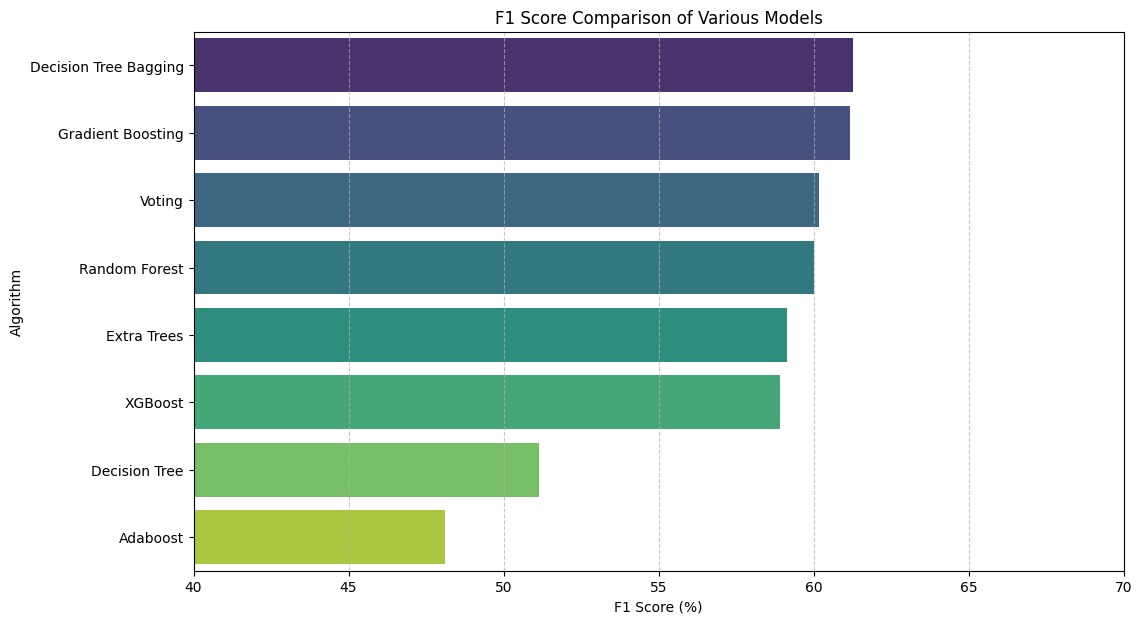

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Collected F1 scores from previous steps
algorithms = [
    "Decision Tree",
    "Decision Tree Bagging",
    "Random Forest",
    "Extra Trees",
    "Adaboost",
    "Gradient Boosting",
    "XGBoost",
    "Voting"
]

f1_scores = [
    51.14, # Decision Tree
    61.27, # Decision Tree Bagging
    60.00, # Random Forest
    59.14, # Extra Trees
    48.10, # Adaboost
    61.18, # Gradient Boosting
    58.93, # XGBoost
    60.17 # Voting
]

df_f1 = pd.DataFrame({
    'Algorithm': algorithms,
    'F1 Score': f1_scores
})

# Sort by F1 Score for better visualization
df_f1 = df_f1.sort_values(by='F1 Score', ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x='F1 Score', y='Algorithm', data=df_f1, palette='viridis')
plt.title('F1 Score Comparison of Various Models')
plt.xlabel('F1 Score (%)')
plt.ylabel('Algorithm')
plt.xlim(40, 70) # Set x-axis limits to better highlight differences
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()